In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
%matplotlib widget

In [3]:
# Import and plot the raw spectra of the aspirin measurements
data_path = Path(r'.')
fig_path = Path(r'./figures')

files = [
    '03_primo_Valence_He-I_2026-06-08__14h45m57s',
    '04_primo_Valence_He-I-killed_2026-06-08__14h51m52s',
    '05_primo_Valence_He-I_2026-06-08__14h56m06s',
    '07_primo_Valence_He-II-killed_2026-06-08__15h16m21s',
    '08_primo_Valence_He-II_2026-06-08__15h59m30s',
    '09_primo_Valence_He-I_2026-06-08__17h27m46s',
    '10_primo_Valence_He-I_2026-06-08__18h09m59s',
    '11_primo_Valence_He-I_2026-06-08__18h16m46s',
    '12_primo_Valence_He-I_2026-06-08__18h25m15s',
    '13_primo_backup_2026-06-08__18h37m19s'   
]

# Load all data
def load_xps(filepath):
    """Load a fixXPS-exported .txt file into a dict of arrays."""
    data = np.genfromtxt(filepath, names=True)
    return {name: data[name] for name in data.dtype.names}

spectra = []   # spectra[i] = {'file_name_1': dict, 'file_name_2': dict, ...}
for i in range(len(files)):
    spectra.append(load_xps(data_path / f'{files[i]}.txt'))

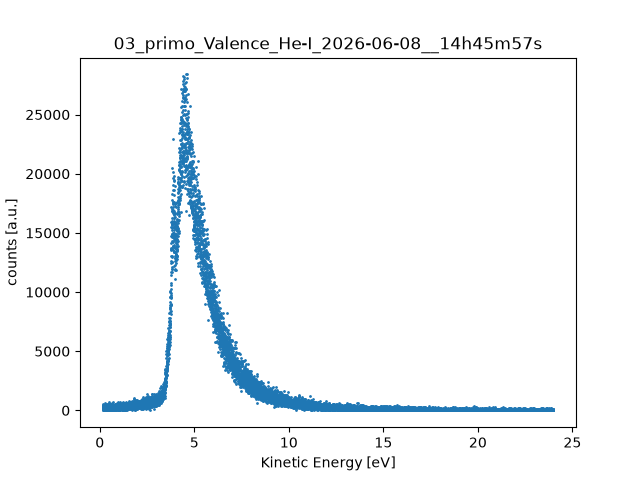

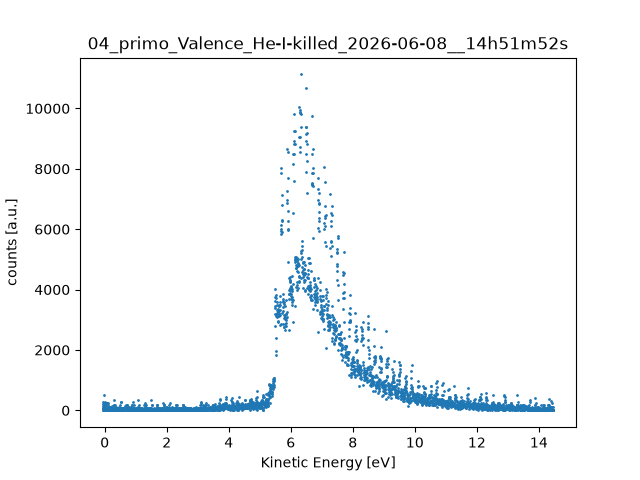

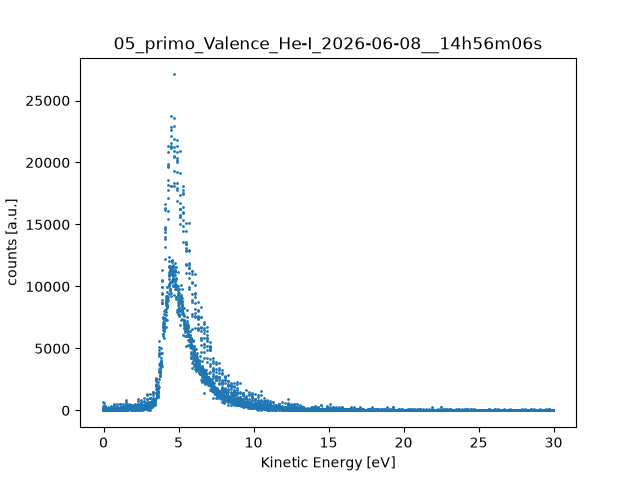

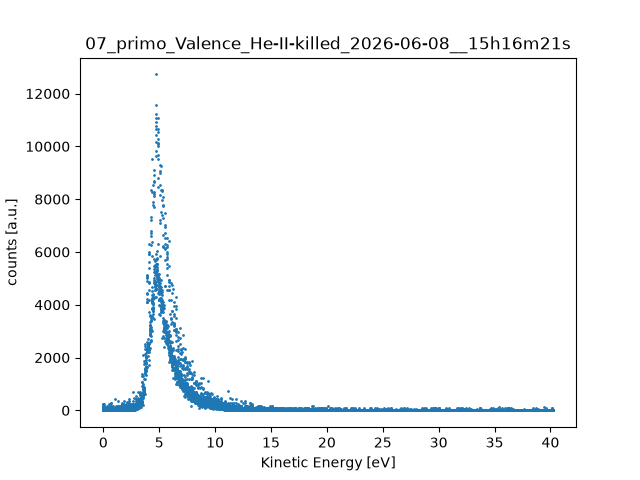

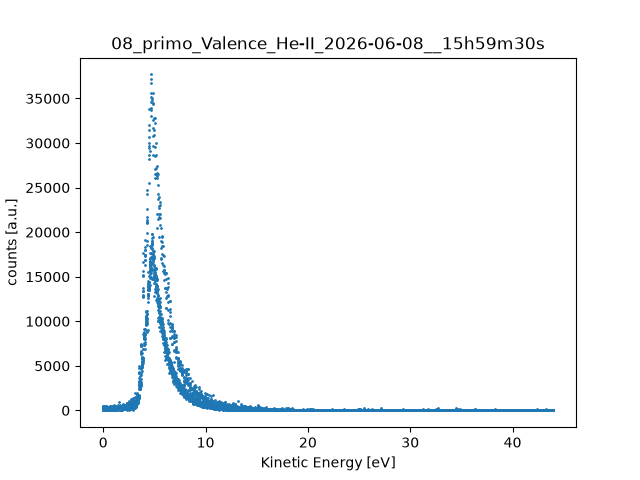

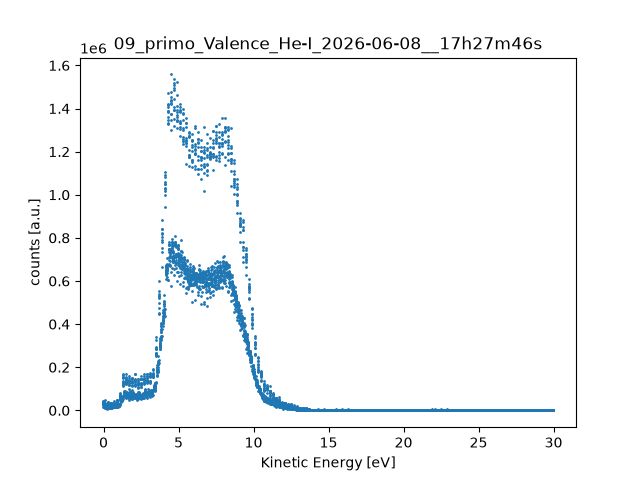

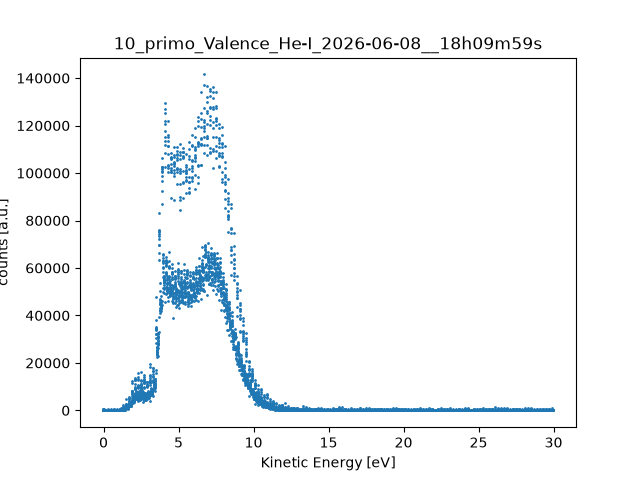

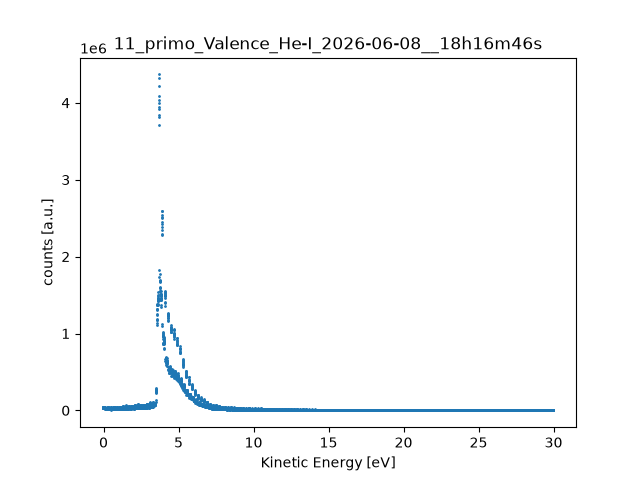

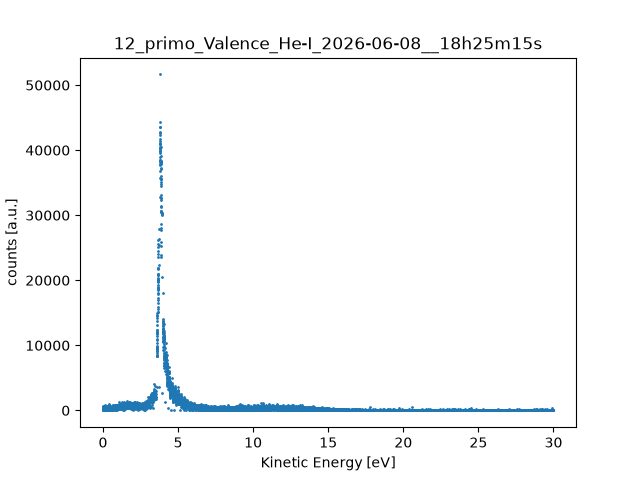

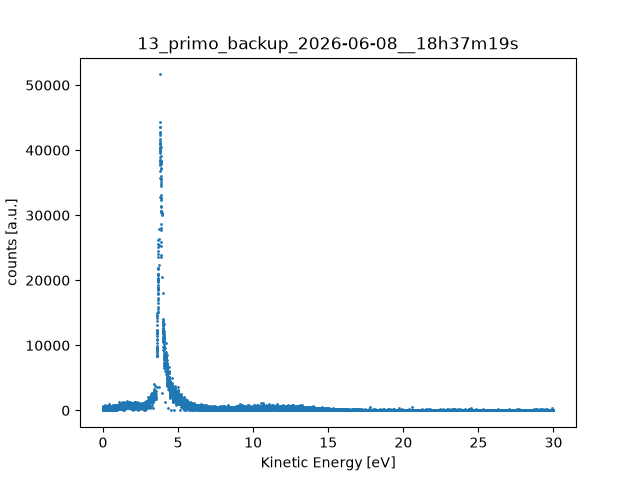

In [4]:
# Plot scatter of Kinetic Energy vs. counts for each imported file
fig_path.mkdir(parents=True, exist_ok=True)

for i in range(len(files)):
    s = spectra[i]
    fig, ax = plt.subplots()
    ax.scatter(s['KE_eV'], s['counts'], s=1)
    ax.set_xlabel('Kinetic Energy [eV]')
    ax.set_ylabel('counts [a.u.]')
    ax.set_title(files[i])
    fig.savefig(fig_path / f'{files[i]}.png', dpi=300, bbox_inches='tight')
    plt.show()